In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
# import libraries
import glob
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib.patches as patches

import nibabel as nib
from nibabel.affines import apply_affine

import xarray as xr

In [3]:
import skimage as ski
from skimage import exposure
from skimage.filters import rank
from skimage.morphology import disk # 2D

In [4]:
np.set_printoptions(suppress=True, precision=4)  # suppresses scientific notation

## Lazy load data

In [ ]:
mri_path = "../data/Johnson_etal_2019_Canine_Atlas_v2/"
mri_file = 'Canine_population_template.nc'
ds = xr.open_dataset(mri_path + mri_file)  

In [16]:
ds

<xarray.Dataset> Size: 24MB
Dimensions:  (y: 200, x: 124, z: 120)
Coordinates:
  * y        (y) float64 2kB -18.02 -17.55 -17.08 -16.61 ... 74.21 74.68 75.15
  * x        (x) float64 992B -27.33 -26.83 -26.33 -25.83 ... 33.1 33.6 34.1
  * z        (z) float64 960B -52.91 -52.44 -51.97 -51.5 ... 1.906 2.374 2.843
Data variables:
    mri      (x, y, z) float64 24MB ...
Attributes:
    affine:           [  0.4995   0.0187  -0.0072 -30.2075   0.0083  -0.0156 ...
    voxel_size_x:     0.49994278
    voxel_size_y:     0.4688
    voxel_size_z:     0.4688
    voxel_size_unit:  mm
    file_name:        Canine_population_template.nii.gz
    file_rel_path:    ../data/Johnson_etal_2019_Canine_Atlas_v2/

In [17]:
def plot_slice(mri_slice, x, y):
    plt.figure(dpi=100)
    mri_slice.plot(x=x, y=y, cmap='gray', vmin=mri_slice.min(), vmax=mri_slice.max())
    plt.plot(0, 0, 'ro')

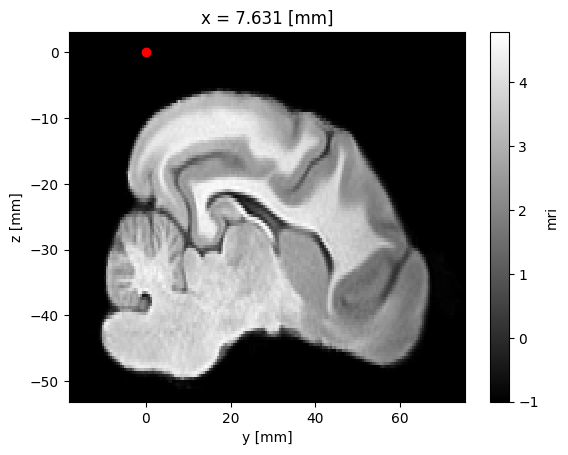

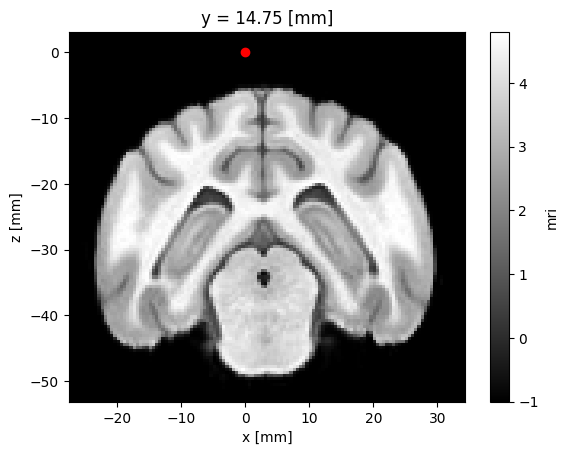

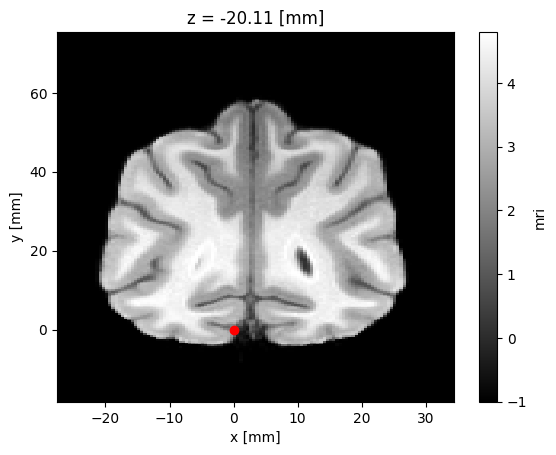

In [18]:
plot_slice(ds.mri.isel(x=70), x='y', y='z')
plot_slice(ds.mri.isel(y=70), x='x', y='z')
plot_slice(ds.mri.isel(z=70), x='x', y='y')

## Adjust contrast for a slice

In [44]:
# select slice of interest
# put the "-1" to "0" and select plane of interest

mri_slice = ds.mri.where(ds.mri>=0, other=0).isel(z=80)

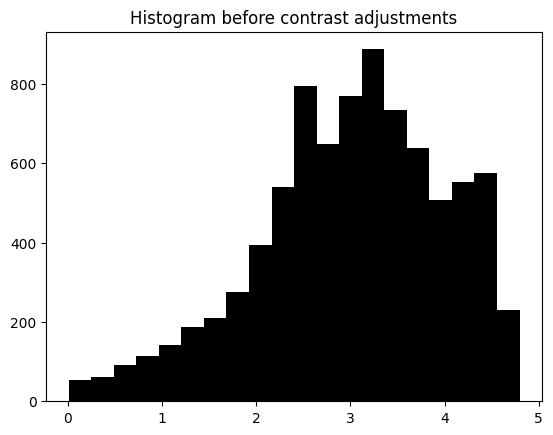

In [20]:
data_to_plot = mri_slice.where(mri_slice>0) 
bin_number = int((np.ceil(data_to_plot.max().values) - np.floor(data_to_plot.min().values)) / 0.25)
data_to_plot = data_to_plot.data.flatten()

plt.figure()
plt.hist(data_to_plot, bins=bin_number, density=False, histtype='bar', facecolor='k')
plt.title("Histogram before contrast adjustments")
plt.show()

In [39]:
def comparative_img_plot(img_array_1, img_array_2, title_2, img_array_3=None,  title_3=None):
    plt.figure(figsize=(15,5))
    
    plt.subplot(1,3,1)
    plt.imshow(img_array_1.T, cmap='gray')
    plt.colorbar()
    plt.title('Before')
    
    plt.subplot(1,3,2)
    plt.imshow(img_array_2.T, cmap='gray')
    plt.colorbar()
    plt.title(title_2)

    if img_array_3 is not None:
        plt.subplot(1,3,3)
        plt.imshow(img_array_3.T, cmap='gray')
        plt.colorbar()
        plt.title(title_3)

    plt.show()

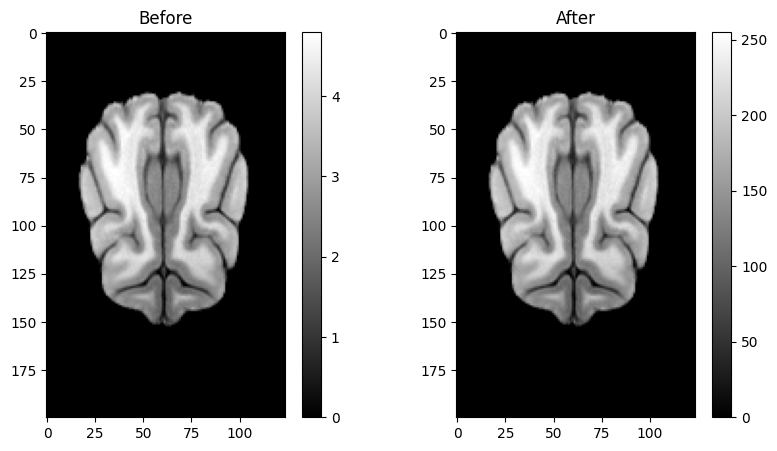

In [40]:
# Contrast stretching
# rescale intensity to 0,255
img_intensity_rescaled = ski.exposure.rescale_intensity(mri_slice.data, in_range='image', out_range=(0, 255))
comparative_img_plot(mri_slice, img_intensity_rescaled, title_2='After')

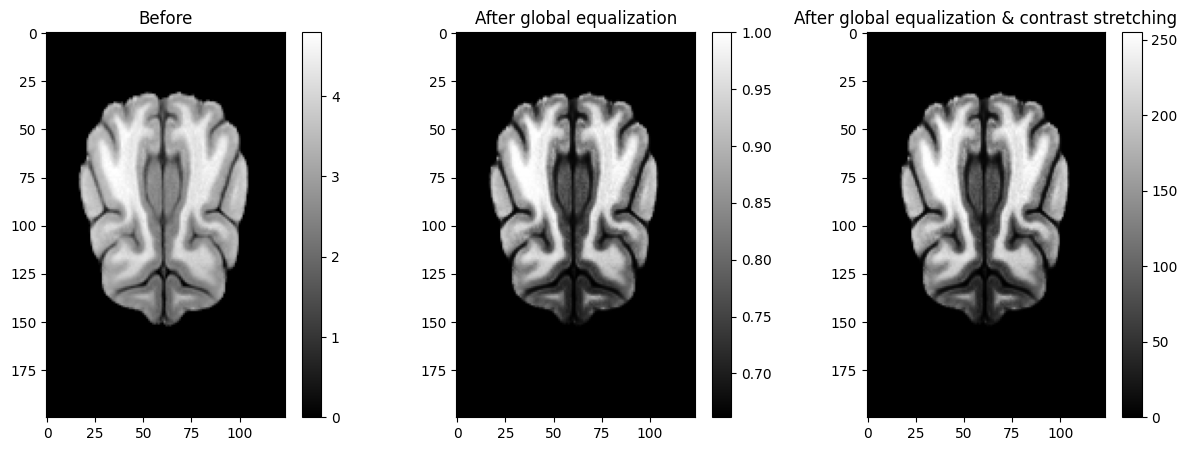

In [42]:
# global equalization
img_global_equalize = exposure.equalize_hist(mri_slice.data)

# & contrast stretching
# rescale intensity to 0,255
img_intensity_rescaled = ski.exposure.rescale_intensity(img_global_equalize, in_range='image', out_range=(0, 255))

# check the difference between "before", equalize only, and then equalize + contrast stretching
comparative_img_plot(img_array_1 = mri_slice, img_array_2= img_global_equalize, img_array_3 = img_intensity_rescaled, 
                     title_2='After global equalization', title_3="After global equalization & contrast stretching")

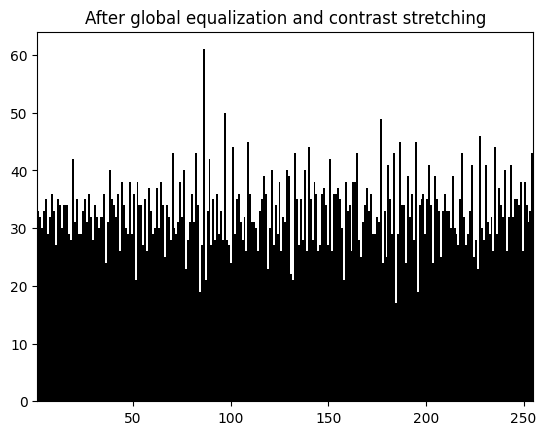

In [ ]:
data_to_plot = np.where(img_intensity_rescaled.ravel()>0,img_intensity_rescaled.ravel(), np.nan)
plt.figure()
plt.hist(data_to_plot, bins=256, density=False, histtype='bar', color='black')
plt.xlim([1,255])
plt.title('After global equalization and contrast stretching')
plt.show()


## Adjust contrast for the MRI volume

In [48]:
mri_volume = ds.mri.where(ds.mri>=0, other=0)
mri_volume

<xarray.DataArray 'mri' (x: 124, y: 200, z: 120)> Size: 24MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * y        (y) float64 2kB -18.02 -17.55 -17.08 -16.61 ... 74.21 74.68 75.15
  * x        (x) float64 992B -27.33 -26.83 -26.33 -25.83 ... 33.1 33.6 34.1
  * z        (z) float64 960B -52.91 -52.44 -51.97 -51.5 ... 1.906 2.374 2.843
Attributes:
    name:     signal intensity

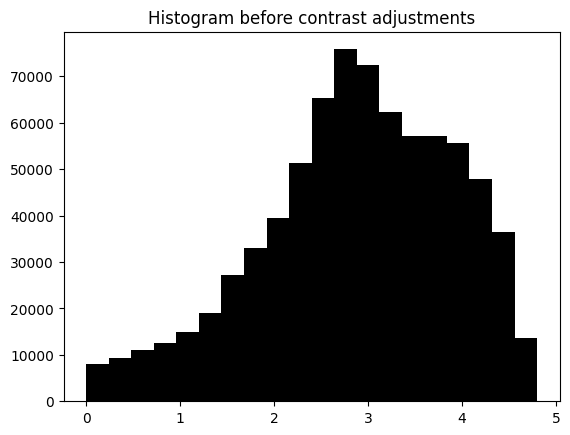

In [49]:
data_to_plot = mri_volume.where(mri_volume>0) 
bin_number = int((np.ceil(data_to_plot.max().values) - np.floor(data_to_plot.min().values)) / 0.25)
data_to_plot = data_to_plot.data.flatten()

plt.figure()
plt.hist(data_to_plot, bins=bin_number, density=False, histtype='bar', facecolor='k')
plt.title("Histogram before contrast adjustments")
plt.show()

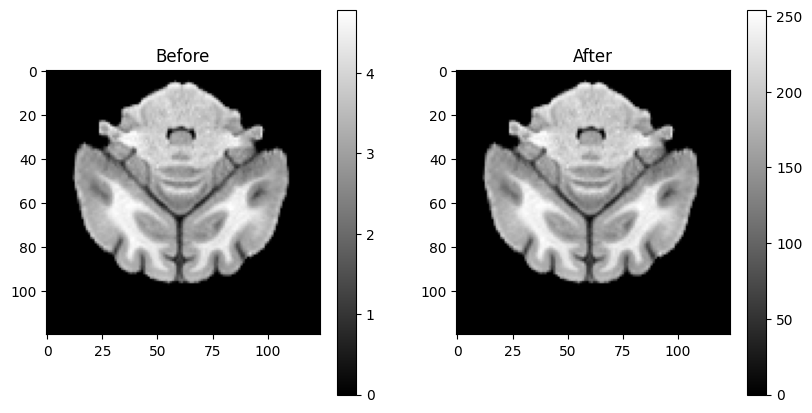

In [52]:
# Contrast stretching
# rescale intensity to 0,255
img_intensity_rescaled = ski.exposure.rescale_intensity(mri_volume.data, in_range='image', out_range=(0, 255))
comparative_img_plot(mri_volume.isel(y=50), img_intensity_rescaled[:,50,:], title_2='After')

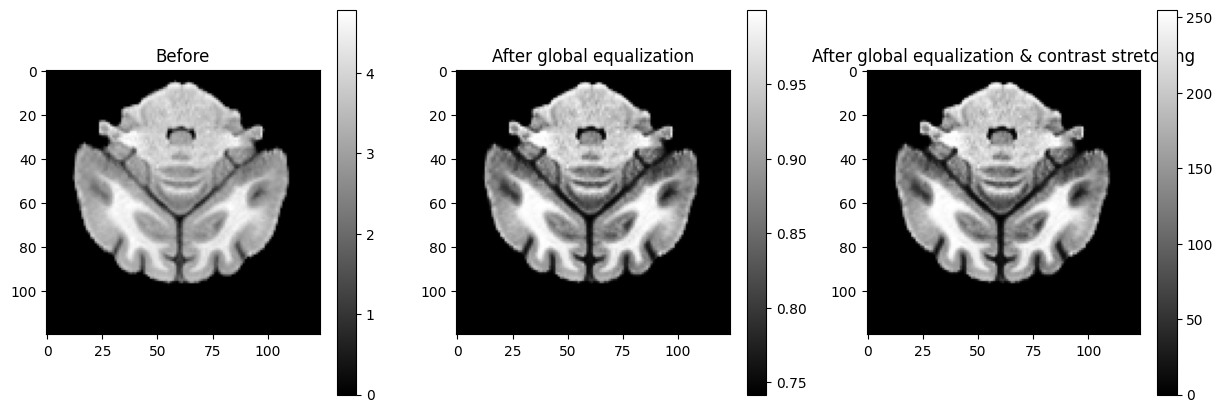

In [53]:
# global equalization
img_global_equalize = exposure.equalize_hist(mri_volume.data)

# & contrast stretching
# rescale intensity to 0,255
img_intensity_rescaled = ski.exposure.rescale_intensity(img_global_equalize, in_range='image', out_range=(0, 255))

# check the difference between "before", equalize only, and then equalize + contrast stretching
comparative_img_plot(img_array_1 = mri_volume.isel(y=50), img_array_2 = img_global_equalize[:,50,:], img_array_3 = img_intensity_rescaled[:,50,:], 
                     title_2='After global equalization', title_3="After global equalization & contrast stretching")

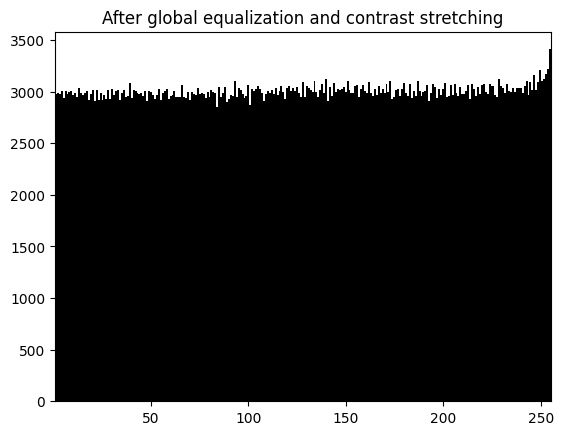

In [54]:
data_to_plot = np.where(img_intensity_rescaled.ravel()>0,img_intensity_rescaled.ravel(), np.nan)
plt.figure()
plt.hist(data_to_plot, bins=256, density=False, histtype='bar', color='black')
plt.xlim([1,255])
plt.title('After global equalization and contrast stretching')
plt.show()

## Make a xarray dataset with contrast adjusted volume
- to keep metadata and coordinates in mm

In [ ]:
ds_contrast_adjusted = xr.Dataset(
    data_vars=dict(
        mri=(["x", "y", "z"], img_intensity_rescaled),
    ),
    coords={'x':ds.x.values, 'y':ds.y.values, 'z':ds.z.values},
    attrs=ds.attrs
    )


# add attributes
ds_contrast_adjusted['x'].attrs = {'name': 'x dimension', "units": "mm", }
ds_contrast_adjusted['y'].attrs = {'name': 'y dimension', "units": "mm", }
ds_contrast_adjusted['z'].attrs = {'name': 'z dimension', "units": "mm", }
ds_contrast_adjusted['mri'].attrs = {'name': 'signal intensity' }

In [60]:
ds_contrast_adjusted

<xarray.Dataset> Size: 24MB
Dimensions:  (x: 124, y: 200, z: 120)
Coordinates:
  * x        (x) float64 992B -27.33 -26.83 -26.33 -25.83 ... 33.1 33.6 34.1
  * y        (y) float64 2kB -18.02 -17.55 -17.08 -16.61 ... 74.21 74.68 75.15
  * z        (z) float64 960B -52.91 -52.44 -51.97 -51.5 ... 1.906 2.374 2.843
Data variables:
    mri      (x, y, z) float64 24MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    affine:           [  0.4995   0.0187  -0.0072 -30.2075   0.0083  -0.0156 ...
    voxel_size_x:     0.49994278
    voxel_size_y:     0.4688
    voxel_size_z:     0.4688
    voxel_size_unit:  mm
    file_name:        Canine_population_template.nii.gz
    file_rel_path:    ../data/Johnson_etal_2019_Canine_Atlas_v2/

Text(0.5, 1.0, 'After contrast adjustment')

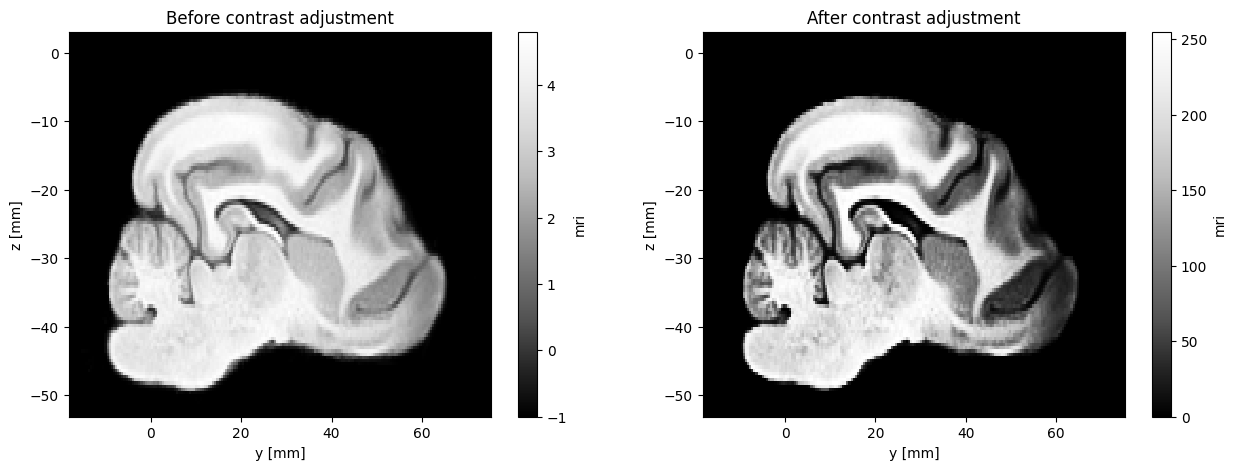

In [84]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
ds.mri.isel(x=50).plot(cmap='Greys_r', x='y', y='z', vmin=ds.mri.min(), vmax=ds.mri.max())
plt.title("Before contrast adjustment")
plt.subplot(1,2,2)
ds_contrast_adjusted.mri.isel(x=50).plot(cmap='Greys_r', x='y', y='z')
plt.title("After contrast adjustment")

Text(0.5, 1.0, 'After contrast adjustment')

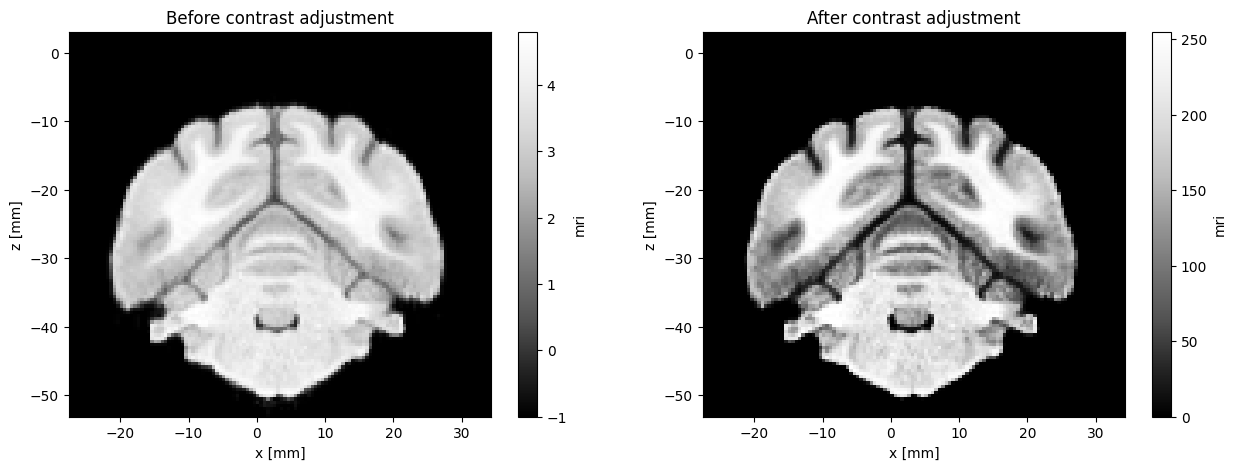

In [83]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
ds.mri.isel(y=50).plot(cmap='Greys_r', x='x', y='z', vmin=ds.mri.min(), vmax=ds.mri.max())
plt.title("Before contrast adjustment")
plt.subplot(1,2,2)
ds_contrast_adjusted.mri.isel(y=50).plot(cmap='Greys_r', x='x', y='z')
plt.title("After contrast adjustment")

Text(0.5, 1.0, 'After contrast adjustment')

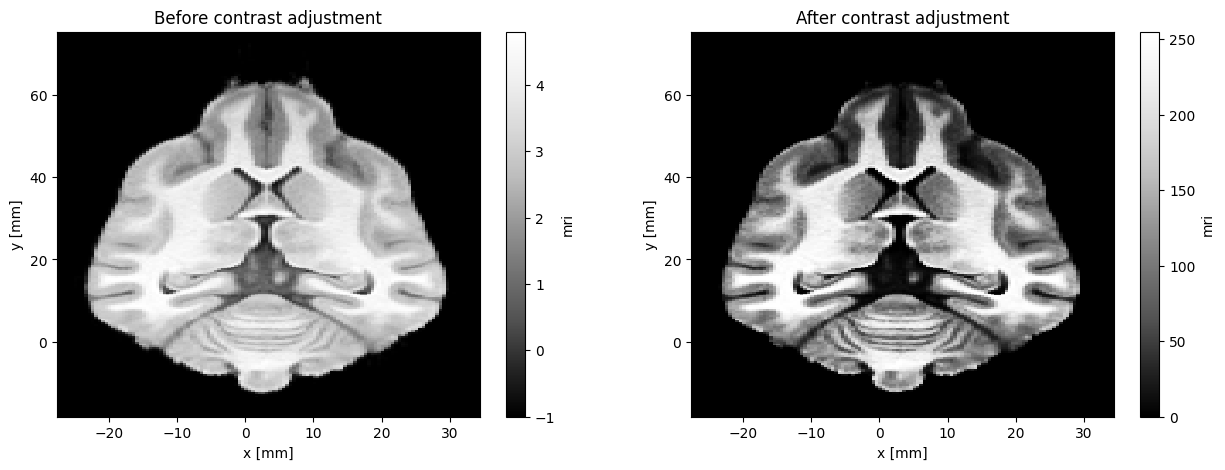

In [82]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
ds.mri.isel(z=50).plot(cmap='Greys_r', x='x', y='y', vmin=ds.mri.min(), vmax=ds.mri.max())
plt.title("Before contrast adjustment")
plt.subplot(1,2,2)
ds_contrast_adjusted.mri.isel(z=50).plot(cmap='Greys_r', x='x', y='y')
plt.title("After contrast adjustment")